In [389]:
from bs4 import BeautifulSoup
import copy
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os
from PIL import Image

In [390]:
edition_directory = "./KuiSCIMA/optical_symbolic_dataset/05_shanghai_manuscript/"
STANZA_SEPARATOR = '<space quantity="1" unit="chars"/>'

table_of_contents = {
    "卷之一": "juan_1",
    "皇朝鐃歌鼓吹曲十四首": "section_shengsongnaogeguchuiqushisishou",
    "琴曲一首": "section_qinquyishou",
    "卷之二": "juan_2",
    "越九歌十首": "section_yuejiuge",
    "帝舜": "song_016_dishunchudiao",
    "王禹": "song_017_wangyuwudiao",
    "越王": "song_018_yuewangyuediao",
    "越相": "song_019_yuexiangceshangdiao",
    "項王": "song_020_xiangwanggupingdiao",
    "濤之神": "song_021_taozhishenshuangdiao",
    "曹娥": "song_022_caoeshucediao",
    "龎󱠥軍": "song_023_pangjiangjungaopingdiao",
    "旌忠": "song_024_jingzhongzhongguanshangdiao",
    "蔡孝子": "song_025_caixiaozizhongguanbanzhandiao",
    "卷之三": "juan_3",
    "令": "section_ling",
    "小重山": "song_026_xiaochongshanling",
    "江梅引": "song_027_jiangmeiyin",
    "驀山溪": "song_028_moshanxi",
    "鶯聲繞紅樓": "song_029_yingshengraohonglou",
    "鬲溪梅令": "song_030_geximeiling",
    "阮郎󲿫二首": "song_031_ruanlanggui",
    "好事近": "song_033_haoshijin",
    "㸃絳唇二首": "song_034_dianjiangchun",
    "虞羙人二首": "song_036_yumeiren",
    "憶王孫": "song_038_yiwangsun",
    "少年遊": "song_039_shaonianyou",
    "鷓鴣天七首": "song_040_zhegutian",
    "夜行舩": "song_047_yexingchuan",
    "杏花天影": "song_048_xinghuatianying",
    "醉󻹐商小品": "song_049_zuiyinshangxiaopin",
    "玉梅令": "song_050_yumeiling",
    "踏莎行": "song_051_tashaxing",
    "訴衷情": "song_052_suzhongqing",
    "浣溪沙六首": "song_053_huanxisha",
    "卷之四": "juan_4",
    "慢": "section_man",
    "霓裳中序第一": "song_059_nishangzhongxu",
    "慶宫春": "song_060_qinggongchun",
    "齊天樂": "song_061_qitianle",
    "滿江紅": "song_062_manjianghong",
    "一萼紅": "song_063_yiehong",
    "念奴嬌二首": "song_064_niannujiao",
    "眉嫵": "song_066_meiwu",
    "月下笛": "song_067_yuexiadi",
    "清波引": "song_068_qingboyin",
    "法曲獻仙音": "song_069_faquxianxianyin",
    "琵琶仙": "song_070_pipaxian",
    "玲瓏四犯": "song_071_linglongsifan",
    "側犯": "song_072_cefan",
    "水龍吟": "song_073_shuilongyin",
    "探春慢": "song_074_tanchunman",
    "八歸": "song_075_bagui",
    "解連𤨔": "song_076_jielianhuan",
    "喜遷鶯": "song_077_xiyingqianman",
    "摸魚兒": "song_078_moyuer",
    "卷之五": "juan_5",
    "自度曲": "section_ziduqu",
    "楊州慢": "song_079_yangzhouman",
    "長亭怨慢": "song_080_changtingyuanman",
    "淡黄栁": "song_081_danhuangliu",
    "石湖仙": "song_082_shihuxian",
    "暗香": "song_083_anxiang",
    "疎影": "song_084_shuying",
    "惜紅衣": "song_085_xihongyi",
    "角󲍾": "song_086_jueshao",
    "徴󲍾": "song_087_zhishao",
    "卷之六": "juan_6",
    "自製曲": "section_zizhiqu",
    "秋宵吟": "song_088_quixiaoyin",
    "凄凉犯": "song_089_qiliangfan",
    "翠樓吟": "song_090_cuilouyin",
    "湘月": "song_091_xiangyue",
}

tei_header = '''<teiHeader> <fileDesc> <titleStmt> <title xml:lang="zh">白石道人歌曲</title> <title xml:lang="zh" type="pinyin">Baishidaoren Gequ</title> <title xml:lang="en">Songs of the Whitestone Daoist</title> <author><persName ref="#person_jiang_kui">Jiang Kui</persName></author> <respStmt> <resp>XML encoding</resp> <persName><forename>Tristan</forename><surname>Repolusk</surname></persName> </respStmt> </titleStmt> <publicationStmt> <publisher><orgName corresp="https://informationsmodellierung.uni-graz.at" ref="http://d-nb.info/gnd/1137284463">Department of Digital Humanities, University of Graz</orgName></publisher> <authority><orgName corresp="https://informationsmodellierung.uni-graz.at" ref="http://d-nb.info/gnd/1137284463">Department of Digital Humanities, University of Graz</orgName></authority> <distributor><orgName ref="https://gams.uni-graz.at">GAMS - Geisteswissenschaftliches Asset Management System</orgName></distributor> <availability> <licence target="https://creativecommons.org/licenses/by-nc/4.0">Creative Commons BY-NC 4.0</licence> <p>The XML encoding is based on the KuiSCIMA dataset, an encoding of several editions of <title>Baishidaoren Gequ</title> in a format based on JSON. It is described in <bibl ref="#bibl_kuiscima">Repolusk &amp; Veas (2025)</bibl> and can be found under <ref target="https://github.com/SuziAI/KuiSCIMA">this link</ref>.</p> </availability> <date when="2025">2025</date> <pubPlace>Graz</pubPlace> </publicationStmt> <seriesStmt> <title ref="https://github.com/SuziAI">SuziAI: Digital Corpus of Jiang Kui's Baishidaoren Gequ</title> <respStmt> <resp>Principal Investigator</resp> <persName><forename>Tristan</forename><surname>Repolusk</surname></persName> </respStmt> </seriesStmt> <sourceDesc> <biblStruct> <analytic> <title xml:lang="zh" type="pinyin">Baishidaoren Gequ</title> <title xml:lang="zh">白石道人歌曲</title> <author><persName ref="#person_jiang_kui" ><surname>Jiang</surname><forename>Kui</forename></persName></author> <editor><persName ref="#person_li_e" ><surname>Li</surname><forename>E</forename></persName></editor> <editor><persName ref="#person_min_hua" ><surname>Min</surname><forename>Hua</forename></persName></editor> <editor><persName ref="#person_wang_zao" ><surname>Wang</surname><forename>Zao</forename></persName></editor> <date when="1736">c. 1736</date> </analytic> <monogr> <ref target="#bibl_yang_2019">Reprinted in Yang, Y. (2019).</ref> <imprint> <date when="2019">2019</date> </imprint> <biblScope unit="page" from="194" to="254">194–254</biblScope> </monogr> <note>This manuscript is called <emph>Shanghai MS</emph> (MS short for manuscript) in the scholarly literature. The original work <title xml:lang="zh" type="pinyin">Baishidaoren Gequ</title> was published in 1202. The Shanghai MS is likely the original working manuscript used for preparing the 1743 Lu edition (or at least a bona fide copy of it). The Shanghai MS is based on a Yuan dynasty manuscript copy called <emph>Tao MS</emph> copied by <persName ref="#person_tao_zongyi">Tao Zongyi</persName>. This information is sourced from <bibl ref="#bibl_yang_2019">Yang, Y. (2019)</bibl>, pp. 21; 23; 191-192, where a facsimile reprint is found in pp. 197–254.</note> </biblStruct> </sourceDesc> </fileDesc> <profileDesc> <langUsage> <language ident="lzh">Literary Chinese</language> </langUsage> <textClass> <keywords scheme="#"> <list> <item><term>Digital Humanities</term></item> <item><term>Song Dynasty</term></item> <item><term>Southern Song</term></item> <item><term>Baishidaoren Gequ</term></item> <item><term>Chinese Musical Notation</term></item> <item><term>Historical Musical Notation</term></item> </list> </keywords> </textClass> </profileDesc> </teiHeader>'''
stand_off = '''<standOff> <listPerson> <person xml:id="person_jiang_kui"> <idno type="VIAF">http://viaf.org/viaf/170520711</idno> <persName> <surname xml:lang="zh">姜</surname> <forename xml:lang="zh">夔</forename> <surname>Jiang</surname> <forename>Kui</forename> </persName> </person> <person xml:id="person_tao_zongyi"> <persName> <surname xml:lang="zh">陶</surname> <forename xml:lang="zh">宗儀</forename> <surname>Tao</surname> <forename>Zongyi</forename> </persName> <birth><date when="1329">1329</date></birth> <death><date when="1412">1412</date></death> <note>Birth and death dates are sourced from <bibl ref="#bibl_yang_2019">Yang, Y. (2019)</bibl>, p. 399.</note> </person> <person xml:id="person_li_e"> <persName> <surname xml:lang="zh">厲</surname> <forename xml:lang="zh">鶚</forename> <surname>Li</surname> <forename>E</forename> </persName> <birth><date when="1692">1692</date></birth> <death><date when="1752">1752</date></death> <note>Birth and death dates are sourced from <bibl ref="#bibl_yang_2019">Yang, Y. (2019)</bibl>, p. 397.</note> </person> <person xml:id="person_min_hua"> <persName> <surname xml:lang="zh">閔</surname> <forename xml:lang="zh">華</forename> <surname>Min</surname> <forename>Hua</forename> </persName> <birth><date when="1697">1697</date></birth> <death><date notBefore="1773">1773</date></death> <note>Birth and death dates are sourced from <bibl ref="#bibl_yang_2019">Yang, Y. (2019)</bibl>, p. 398.</note> </person> <person xml:id="person_wang_zao"> <persName> <surname xml:lang="zh">王</surname> <forename xml:lang="zh">藻</forename> <surname>Wang</surname> <forename>Zao</forename> <note>Birth and death dates are missing in <bibl ref="#bibl_yang_2019">Yang, Y. (2019)</bibl>.</note> </persName> </person> </listPerson> <listBibl> <biblStruct xml:id="bibl_yang_2019"> <monogr> <author> <persName> <surname>Yang</surname> <forename>Yuanzheng</forename> </persName> </author> <title>Plum blossom on the far side of the stream. the renaissance of Jiang Kui's lyric oeuvre with facsimiles and a new critical edition of The Songs of the Whitestone Daoist.</title> <imprint> <publisher>Hong Kong University Press</publisher> <date when="2019">2019</date> </imprint> </monogr> </biblStruct> <biblStruct xml:id="bibl_kuiscima"> <analytic> <author> <persName> <surname>Repolusk</surname> <forename>Tristan</forename> </persName> </author> <author> <persName> <surname>Veas</surname> <forename>Eduardo</forename> </persName> </author> <title level="a">KuiSCIMA v2.0: Improved Baselines, Calibration, and Cross-Notation Generalization for Historical Chinese Music Notations in Jiang Kui's Baishidaoren Gequ</title> </analytic> <monogr> <title level="m">Document Analysis and Recognition - ICDAR 2025</title> <editor> <persName> <forename>Xu-Cheng</forename> <surname>Yin</surname> </persName> <persName> <forename>Dimosthenis</forename> <surname>Karatzas</surname> </persName> <persName> <forename>Daniel</forename> <surname>Lopresti</surname> </persName> </editor> <imprint> <publisher>Springer Nature Switzerland</publisher> <pubPlace>Cham</pubPlace> <date when="2025">2025</date> </imprint> <biblScope unit="page" from="116" to="132">116–132</biblScope> </monogr> </biblStruct> </listBibl> </standOff>'''


In [391]:
import dataclasses

@dataclasses.dataclass
class GongcheMelodySymbol:
    HE: str = "HE"
    XIA_SI: str = "XIA_SI"
    SI: str = "SI"
    XIA_YI: str = "XIA_YI"
    YI: str = "YI"
    SHANG: str = "SHANG"
    GOU: str = "GOU"
    CHE: str = "CHE"
    XIA_GONG: str = "XIA_GONG"
    GONG: str = "GONG"
    XIA_FAN: str = "XIA_FAN"
    FAN: str = "FAN"
    LIU: str = "LIU"
    XIA_WU: str = "XIA_WU"
    WU: str = "WU"
    GAO_WU: str = "GAO_WU"
    
    @classmethod
    def to_gongche(cls, symbol):
        try:
            return {
                GongcheMelodySymbol.HE: "合",
                GongcheMelodySymbol.XIA_SI: "下四",
                GongcheMelodySymbol.SI: "四",
                GongcheMelodySymbol.XIA_YI: "下一",
                GongcheMelodySymbol.YI: "一",
                GongcheMelodySymbol.SHANG: "上",
                GongcheMelodySymbol.GOU: "勾",
                GongcheMelodySymbol.CHE: "尺",
                GongcheMelodySymbol.XIA_GONG: "下工",
                GongcheMelodySymbol.GONG: "工",
                GongcheMelodySymbol.XIA_FAN: "下凡",
                GongcheMelodySymbol.FAN: "凡",
                GongcheMelodySymbol.LIU: "六",
                GongcheMelodySymbol.XIA_WU: "下五",
                GongcheMelodySymbol.WU: "五",
                GongcheMelodySymbol.GAO_WU: "高"
            }[symbol]
        except KeyError:
            return "INVALID"
            

@dataclasses.dataclass
class ExtendedLvlv:
    HUANGZHONG: str = "HUANGZHONG"
    DALV: str = "DALV"
    TAICU: str = "TAICU"
    JIAZHONG: str = "JIAZHONG"
    GUXIAN: str = "GUXIAN"
    ZHONGLV: str = "ZHONGLV"
    RUIBIN: str = "RUIBIN"
    LINZHONG: str = "LINZHONG"
    YIZE: str = "YIZE"
    NANLV: str = "NANLV"
    WUYI: str = "WUYI"
    YINGZHONG: str = "YINGZHONG"
    HUANGZHONG_QING: str = "HUANGZHONG_QING"
    DALV_QING: str = "DALV_QING"
    TAICU_QING: str = "TAICU_QING"
    JIAZHONG_QING: str = "JIAZHONG_QING"
    ZHE_ZI: str = "ZHE_ZI"

    @classmethod
    def to_gongche_melody_symbol(cls, lvlv):
        return {
            cls.HUANGZHONG: GongcheMelodySymbol.HE,
            cls.DALV: GongcheMelodySymbol.XIA_SI,
            cls.TAICU: GongcheMelodySymbol.SI,
            cls.JIAZHONG: GongcheMelodySymbol.XIA_YI,
            cls.GUXIAN: GongcheMelodySymbol.YI,
            cls.ZHONGLV: GongcheMelodySymbol.SHANG,
            cls.RUIBIN: GongcheMelodySymbol.GOU,
            cls.LINZHONG: GongcheMelodySymbol.CHE,
            cls.YIZE: GongcheMelodySymbol.XIA_GONG,
            cls.NANLV: GongcheMelodySymbol.GONG,
            cls.WUYI: GongcheMelodySymbol.XIA_FAN,
            cls.YINGZHONG: GongcheMelodySymbol.FAN,
            cls.HUANGZHONG_QING: GongcheMelodySymbol.LIU,
            cls.DALV_QING: GongcheMelodySymbol.XIA_WU,
            cls.TAICU_QING: GongcheMelodySymbol.WU,
            cls.JIAZHONG_QING: GongcheMelodySymbol.GAO_WU
        }[lvlv]

    @classmethod
    def to_name(cls, lvlv):
        return {
            cls.HUANGZHONG: "黃",
            cls.DALV: "大",
            cls.TAICU: "太",
            cls.JIAZHONG: "夾",
            cls.GUXIAN: "姑",
            cls.ZHONGLV: "仲",
            cls.RUIBIN: "蕤",
            cls.LINZHONG: "林",
            cls.YIZE: "夷",
            cls.NANLV: "南",
            cls.WUYI: "無",
            cls.YINGZHONG: "應",
            cls.HUANGZHONG_QING: "黃清",
            cls.DALV_QING: "大清",
            cls.TAICU_QING: "太清",
            cls.JIAZHONG_QING: "夹清",
            cls.ZHE_ZI: "折字",
        }[lvlv]

    @classmethod
    def from_name(cls, lvlv):
        return {
            "黃": cls.HUANGZHONG,
            "大": cls.DALV,
            "太": cls.TAICU,
            "夾": cls.JIAZHONG,
            "姑": cls.GUXIAN,
            "仲": cls.ZHONGLV,
            "蕤": cls.RUIBIN,
            "林": cls.LINZHONG,
            "夷": cls.YIZE,
            "南": cls.NANLV,
            "無": cls.WUYI,
            "應": cls.YINGZHONG,
            "黃清": cls.HUANGZHONG_QING,
            "大清": cls.DALV_QING,
            "太清": cls.TAICU_QING,
            "夹清": cls.JIAZHONG_QING,
            "折字": cls.ZHE_ZI,
        }[lvlv]

    @classmethod
    def from_class(cls, idx):
        return dataclasses.astuple(cls())[idx]

    @classmethod
    def to_class(cls, extended_lvlv):
        try:
            return dataclasses.astuple(cls()).index(extended_lvlv)
        except ValueError:
            return 7  # LINZHONG


@dataclasses.dataclass
class SuzipuAdditionalSymbol:
    ADD_DA_DUN: str = "DA_DUN"
    ADD_XIAO_ZHU: str = "XIAO_ZHU"
    ADD_DING_ZHU: str = "DING_ZHU"
    ADD_DA_ZHU: str = "DA_ZHU"
    ADD_ZHE: str = "ZHE"
    ADD_YE: str = "YE"

    @classmethod
    def to_name(cls, additional_symbol):
        if additional_symbol is None:
            return ""
        return {
            cls.ADD_DA_DUN: "頓",
            cls.ADD_XIAO_ZHU: "小",
            cls.ADD_DING_ZHU: "丁",
            cls.ADD_DA_ZHU: "大",
            cls.ADD_ZHE: "折",
            cls.ADD_YE: "拽"
        }[additional_symbol]

In [392]:
def boxes_to_coordinates(boxes, key: str):
    x_min = np.inf
    x_max = 0
    y_min = np.inf
    y_max = 0
    
    for box in boxes:
        (x1, y1), (x2, y2) = box[key]
        x_min = min(x1, x2, x_min)
        x_max = max(x1, x2, x_max)
        y_min = min(y1, y2, y_min)
        y_max = max(y1, y2, y_max)

    return ((x_min, y_min), (x_max, y_max))

def add_pb_and_lb(box):
    tei_string = ""
    if "tei_pb" in box:
        tei_string += f'<pb n="{box["tei_pb"]["n"]}" facs="#{box["tei_pb"]["facs"]}"/>'
    if "tei_lb" in box:
        tei_string += f'<lb facs="#{box["tei_lb"]}"/>'
    return tei_string

In [464]:
class Line:
    def __init__(self, boxes: list):
        self.boxes = boxes

    def __len__(self):
        return len(self.boxes)

    def __iter__(self):
        return iter(self.boxes)

    def __getitem__(self, idx: int):
        return self.boxes[idx]

    def __delitem__(self, idx: int):
        del self.boxes[idx]

    def append(self, item):
        self.boxes.append(item)

        
class TextLine(Line):
    def __repr__(self):
        return f"TextLine({"".join([box["text_content"] for box in self.boxes])})"

    def coordinates(self):
        return boxes_to_coordinates(self.boxes, key="text_coordinates")

    def page(self):
        return self.boxes[0]["text_page"]
        

class LyricsLine(Line):
    def __repr__(self):
        return f"LyricsLine({"".join([box["text_content"] for box in self.boxes])})"

    def coordinates(self):
        return boxes_to_coordinates(self.boxes, key="text_coordinates")

    def page(self):
        return self.boxes[0]["text_page"]


class MusicLine(Line):
    def __repr__(self):
        return f"MusicLine({"".join(["*" for box in self.boxes])})"

    def coordinates(self):
        return boxes_to_coordinates(self.boxes, key="notation_coordinates")

    def page(self):
        return self.boxes[0]["notation_page"]


class IndependentMusicLine(Line):
    def __repr__(self):
        return f"IndependentMusicLine({"".join(["*" for box in self.boxes])})"

    def coordinates(self):
        return boxes_to_coordinates(self.boxes, key="notation_coordinates")

    def page(self):
        return self.boxes[0]["notation_page"]

class EmptyPageLine(Line):
    def __init__(self, image_path: str):
        super().__init__([{}])
        self.page_file = os.path.basename(image_path)
        
    def __repr__(self):
        return f"EmptyPageLine({self.page_file})"

    def page(self):
        return self.page_file


class CombinedLine:
    def __init__(self, notation_boxes, lyrics_boxes):
        self.notation_boxes = notation_boxes
        self.lyrics_boxes = lyrics_boxes
        
    def __len__(self):
        return len(self.notation_boxes) + len(self.lyrics_boxes)

    def __repr__(self):
        return f"CombinedLine({"".join(["*" for box in self.notation_boxes])}{"".join([box["text_content"] for box in self.lyrics_boxes])})"

In [550]:
def transform_coordinates(box, images):
    (x, y), (x2, y2) = box
    offset = 0
    for page_idx, page in enumerate(images[::-1]):  # pages are read from right to left
        offset += page.width
        if x < offset:
            break
    
    correct_page_idx = len(images)-1-page_idx
    x_offset = offset-page.width

    return correct_page_idx, ((x-x_offset, y), (x2-x_offset, y2))

def segment_boxes_into_lines(boxes: list, images: list[Image]):
    raw_lines = []
    for box in boxes:
        if "notation_coordinates" in box and box["notation_coordinates"] is not None:
            page_idx, new_box = transform_coordinates(box["notation_coordinates"], images)
            box["notation_coordinates"] = new_box
            box["notation_page"] = os.path.basename(images[page_idx].filename)
        if "text_coordinates" in box and box["text_coordinates"] is not None:
            page_idx, new_box = transform_coordinates(box["text_coordinates"], images)
            box["text_coordinates"] = new_box
            box["text_page"] = os.path.basename(images[page_idx].filename)
        if len(raw_lines) == 0 or raw_lines[-1][-1]["is_line_break"]:
            raw_lines.append([box])
        else:
            raw_lines[-1].append(box)
        

    lines = []
    for line in raw_lines:
        line_types = set([box["box_type"] for box in line])
        if len(line_types) == 1 and "Music" in line_types:
            if line[0]["notation_content"] is not None:
                lines.append(MusicLine(copy.deepcopy(line)))
            if line[0]["text_content"] is not None:
                lines.append(LyricsLine(line))
        elif "Music" not in line_types:
            lines.append(TextLine(line))
        else:
            print("WARNING:", line_types)
            print("".join([box["text_content"] for box in line]))
            print([image.filename for image in images])
            print()
            
    return lines

def segment_boxes_into_lines_suzipu(boxes: list, images: list[Image]):
    # We have a problem in suzipu pieces, where the stanzas are separated
    # by a blank space. Since both the notation and lyrics end simultaneously
    # after the first stanza, we have two physical line breaks, one for the notation,
    # the other one for the text. This is not compatible with basic column regions,
    # so we split the notation and lyrics columns into two subcolumns to avoid problems.
    lines = segment_boxes_into_lines(boxes, images)

    new_lines = []
    split_index = None
    for line_idx, line in enumerate(lines):
        length = len(line)
        separation_index = -1
        
        if isinstance(line, MusicLine):
            t = MusicLine
            for box_idx, box in enumerate(line):
                if box["notation_content"] is None or box["notation_content"]["pitch"] in (None, "", " "):
                    separation_index = box_idx
                    break
        elif isinstance(line, LyricsLine):
            t = LyricsLine
            for box_idx, box in enumerate(line):
                if box["text_content"] in (None, "", " "):
                    separation_index = box_idx
                    break
        else:
            new_lines.append(line)
            continue
            
        if separation_index not in (-1, 0, length-1):
            new_lines += [t(line[:separation_index+1]), t(line[separation_index+1:])]
            if split_index is None:
                split_index = line_idx
        else:
            new_lines.append(line)
    
    if split_index is not None:
        return new_lines[:split_index+1] + [new_lines[split_index+2], new_lines[split_index+1]] + new_lines[split_index+3:]
    else:
        return new_lines


def segment_boxes_into_lines_guyuan(boxes: list, images: list[Image]):
    raw_lines = []
    for box in boxes:
        if "notation_coordinates" in box and box["notation_coordinates"] is not None:
            page_idx, new_box = transform_coordinates(box["notation_coordinates"], images)
            box["notation_coordinates"] = new_box
            box["notation_page"] = os.path.basename(images[page_idx].filename)
        if "text_coordinates" in box and box["text_coordinates"] is not None:
            page_idx, new_box = transform_coordinates(box["text_coordinates"], images)
            box["text_coordinates"] = new_box
            box["text_page"] = os.path.basename(images[page_idx].filename)
        if len(raw_lines) == 0 or raw_lines[-1][-1]["is_line_break"]:
            raw_lines.append([box])
        else:
            raw_lines[-1].append(box)

    lines = []
    for line in raw_lines:
        line_types = set([box["box_type"] for box in line])
        if len(line_types) == 1 and "Music" in line_types:
            if line[0]["notation_content"] is not None and len(set([box["text_content"] for box in line])) == 1:
                lines.append(IndependentMusicLine(copy.deepcopy(line)))
            else:
                if line[0]["notation_content"] is not None:
                    lines.append(MusicLine(copy.deepcopy(line)))
                if line[0]["text_content"] is not None:
                    lines.append(LyricsLine(line))
        elif "Music" not in line_types:
            lines.append(TextLine(line))
            
    return lines

def add_content_with_comment(box):
    tei_string = ""
    if "tei_start_comment" in box:
        tei_string += '<seg rend="small" type="note">'
    tei_string += box["text_content"]
    if "tei_end_comment" in box:
        tei_string += '</seg>'
    return tei_string

In [662]:
class JsonBased:
    def __init__(self, file_path: str):
        with open(file_path, "r") as file_handle:
            self.json = json.load(file_handle)
        self.boxes = self.json["content"]
        self.image_files = self.json["images"]
        self.file = os.path.basename(file_path)
        images = [Image.open(os.path.join(os.path.dirname(file_path), image_file)) for image_file in self.image_files]
        self.physical_lines = segment_boxes_into_lines(self.boxes, images)

class TextOnlySong(JsonBased):
    def __init__(self, *args, comment=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.title = "".join([box["text_content"] for box in self.boxes if box["box_type"] == "Title"])

        # Update logical lines
        self.logical_lines = [LyricsLine([])]
        for lyric_box in [box for line in self.physical_lines for box in line if isinstance(line, LyricsLine)]:
            if lyric_box["text_content"] in (None, "", " "):
                self.logical_lines.append(LyricsLine([]))
            else:
                self.logical_lines[-1].append(lyric_box)

        # Update boxes accordingly
        self.boxes = [box for line in self.physical_lines for box in line]

        # Mark the comment
        comment_found = False
        if comment is not None and len(comment) > 0:
            for box_idx in range(len(self.boxes) - len(comment) + 1):
                box_text = "".join([box["text_content"] for box in self.boxes[box_idx:box_idx+len(comment)]])
                if box_text == comment:
                    self.boxes[box_idx]["tei_start_comment"] = True
                    self.boxes[box_idx+len(comment)-1]["tei_end_comment"] = True
                    comment_found = True
                    break
            if not comment_found:
                print(f"WARNING! COMMENT {comment} WAS NOT FOUND")
            

    def __str__(self):
        return f"TextOnlySong({self.title}, {self.file})"
    
    def to_tei(self):
        tei_string = ""

        # First, title
        title_line = self.physical_lines[0]
        tei_string += "<head><title>"
        tei_string += add_pb_and_lb(title_line[0])
        for box in title_line:
            if box["box_type"] == "Title":
                tei_string += add_content_with_comment(box)
        tei_string += "</title>"
        if "Mode" in [box["box_type"] for box in title_line]:
            tei_string += '<seg rend="small" type="mode">'
            for box in title_line:
                if box["box_type"] == "Mode":
                    tei_string += add_content_with_comment(box)
            tei_string += "</seg>"
        tei_string += "</head>"
        
        # Second, preface
        preface_lines = [line for line in self.physical_lines if "Preface" in [box["box_type"] for box in line]]
        if len(preface_lines):
            tei_string += '<p ana="description">'
            for line in preface_lines:
                for box in line:
                    if box["box_type"] == "Preface":
                        tei_string += add_pb_and_lb(box)
                        tei_string += add_content_with_comment(box)
            last_line = preface_lines[-1]
            if "Mode" in [box["box_type"] for box in last_line]:
                tei_string += '<seg rend="small" type="mode">'
                for box in last_line:
                    if box["box_type"] == "Mode":
                        tei_string += box["text_content"]
                tei_string += "</seg>"
            tei_string += "</p>"

        # Third, lyrics
        tei_string += "<lg>"
        for line in self.logical_lines:
            tei_string += "<l>"
            for box in line:
                tei_string += add_pb_and_lb(box)
                tei_string += add_content_with_comment(box)
            tei_string += f"</l>{STANZA_SEPARATOR}"  # add a stanza separator between each stanza
        tei_string = tei_string[:-len(STANZA_SEPARATOR)]  # remove the last stanza separator
        tei_string += "</lg>"

        return f'<div type="song" xml:id="song_{self.file.split(".")[0]}">{tei_string}</div>'


class BiejiSong(JsonBased):
    def __init__(self, file_path: str, switch_order: bool = False):
        with open(file_path, "r") as file_handle:
            self.json = json.load(file_handle)
        self.boxes = self.json["content"]
        self.image_files = self.json["images"]
        self.file = os.path.basename(file_path)
        images = [Image.open(os.path.join(os.path.dirname(file_path), image_file)) for image_file in self.image_files]

        # Update box order accordingly
        self.switch_order = switch_order
        
        if switch_order:
            text_boxes = [box for box in self.boxes if box["box_type"] != "Music"]
            music_boxes = [box for box in self.boxes if box["box_type"] == "Music"]
            self.boxes = music_boxes + text_boxes

        # Update physical lines
        self.physical_lines = segment_boxes_into_lines(self.boxes, images)

        # Update logical lines
        self.logical_lines = [LyricsLine([])]
        for lyric_box in [box for line in self.physical_lines for box in line if isinstance(line, LyricsLine)]:
            if lyric_box["text_content"] in (None, "", " "):
                self.logical_lines.append(LyricsLine([]))
            else:
                self.logical_lines[-1].append(lyric_box)
        
        # Update boxes accordingly
        self.boxes = [box for line in self.physical_lines for box in line]

    def __str__(self):
        return f"BiejiSong({self.file})"
    
    def to_tei(self):
        tei_string = ""

        if self.switch_order:
        # if the order is switched, we have lyrics before the preface.
        # In this case, we never have a title (pieces 095-101)
            tei_string += "<lg>"
            for line in self.logical_lines:
                tei_string += "<l>"
                for box in line:
                    tei_string += add_pb_and_lb(box)
                    tei_string += box["text_content"]
                tei_string += f"</l>{STANZA_SEPARATOR}"  # add a stanza separator between each stanza
            tei_string = tei_string[:-len(STANZA_SEPARATOR)]  # remove the last stanza separator
            tei_string += "</lg>"
            
            preface_lines = [line for line in self.physical_lines if "Preface" in [box["box_type"] for box in line]]
            if len(preface_lines):
                tei_string += '<p ana="description">'
                for line in preface_lines:
                    for box in line:
                        if box["box_type"] == "Preface":
                            tei_string += add_pb_and_lb(box)
                            tei_string += box["text_content"]
                tei_string += '</p>'
        else:
            # otherwise, we have two other cases:
            box_types = [box["box_type"] for box in self.boxes]
            try:
                preface_first = box_types.index("Preface") < box_types.index("Title")
            except ValueError:  # if no title box is found
                preface_first = False
                
            if preface_first:
                # 1) First preface, then title, then lyrics
                preface_boxes = [box for box in self.boxes if box["box_type"] == "Preface"]
                if len(preface_boxes):
                    tei_string += '<p ana="description">'
                    for box in preface_boxes:
                        tei_string += add_pb_and_lb(box)
                        tei_string += box["text_content"]
                        
                    title_boxes = [box for box in self.boxes if box["box_type"] == "Title"]
                    if len(title_boxes):
                        tei_string += '<title>'
                        for box in title_boxes:
                            tei_string += box["text_content"]
                        tei_string += '</title>'
                    tei_string += '</p>'

                tei_string += "<lg>"
                for line in self.logical_lines:
                    tei_string += "<l>"
                    for box in line:
                        tei_string += add_pb_and_lb(box)
                        tei_string += box["text_content"]
                    tei_string += f"</l>{STANZA_SEPARATOR}"  # add a stanza separator between each stanza
                tei_string = tei_string[:-len(STANZA_SEPARATOR)]  # remove the last stanza separator
                tei_string += "</lg>"
                        
            else:
                # 2) Optional title, then preface, then lyrics
                title_boxes = [box for box in self.boxes if box["box_type"] == "Title"]
                if len(title_boxes):
                    tei_string += '<head><title>'
                    for box in title_boxes:
                        tei_string += box["text_content"]
                    tei_string += '</title></head>'

                preface_boxes = [box for box in self.boxes if box["box_type"] == "Preface"]
                if len(preface_boxes):
                    tei_string += '<p ana="description">'
                    for box in preface_boxes:
                        tei_string += add_pb_and_lb(box)
                        tei_string += box["text_content"]
                    tei_string += '</p>'
                    
                tei_string += "<lg>"
                for line in self.logical_lines:
                    tei_string += "<l>"
                    for box in line:
                        tei_string += add_pb_and_lb(box)
                        tei_string += box["text_content"]
                    tei_string += "</l> "  # add a stanza separator between each stanza
                tei_string = tei_string[:-1]  # remove the last stanza separator
                tei_string += "</lg>"

        return f'<div type="song" xml:id="song_{self.file.split(".")[0]}">{tei_string}</div>'
                

class GuyuanSong(JsonBased):
    def __init__(self, file_path: str):
        with open(file_path, "r") as file_handle:
            self.json = json.load(file_handle)
        self.boxes = self.json["content"]
        self.image_files = self.json["images"]
        self.file = os.path.basename(file_path)
        images = [Image.open(os.path.join(os.path.dirname(file_path), image_file)) for image_file in self.image_files]
        self.physical_lines = segment_boxes_into_lines_guyuan(self.boxes, images)
        
        self.title = "".join([box["text_content"] for box in self.boxes if box["box_type"] == "Title"])

        grouped_lines = [[]]
        for line in self.physical_lines:
            if isinstance(line, (MusicLine, IndependentMusicLine)):
                grouped_lines.append([line])
            else:
                grouped_lines[-1].append(line)

        preprocessed_lines = []
        for line in grouped_lines:
            is_new_group = False
            if len(line) == 2:
                notation_line, lyrics_line = line
                if lyrics_line[-1]["text_content"] in (None, "", " "):
                    is_new_group = True
                    notation_line = notation_line[:-1]  # remove the line break space
                    lyrics_line = lyrics_line[:-1]  # remove the line break space
                new_line = CombinedLine(notation_line, lyrics_line)
            elif isinstance(line[0], (LyricsLine)):
                lyrics_line = line[0]
                if lyrics_line[-1]["text_content"] in (None, "", " "):
                    is_new_group = True
                    lyrics_line = lyrics_line[:-1]  # remove the line break space
                new_line = CombinedLine([], lyrics_line)
            elif isinstance(line[0], (IndependentMusicLine)):
                notation_line = line[0]
                if "''" in str(notation_line[-1]["notation_content"]):
                    is_new_group = True
                    notation_line = notation_line[:-1]  # remove the line break space
                new_line = CombinedLine(notation_line, [])
            else:
                continue

            preprocessed_lines.append(new_line)
            if is_new_group:
                preprocessed_lines.append(None)

        self.logical_lines = [[]]
        for line in preprocessed_lines:
            if line is None:
                self.logical_lines.append([])
            else:
                self.logical_lines[-1].append(line)
        del self.logical_lines[-1]  # delete last []
        
        
                
        return

        # Update boxes accordingly
        self.boxes = [box for line in self.physical_lines for box in line]

    def __str__(self):
        return f"GuyuanSong({self.title}, {self.file})"
    
    def to_tei(self):
        tei_string = ""

        title_or_mode_line = self.physical_lines[0]
        tei_string += '<head><title>'
        for box in title_or_mode_line:
            if box["box_type"] == "Title":
                tei_string += box["text_content"]
        tei_string += '</title>'
        tei_string += '</head>'

        preface_or_mode_lines = [line for line in self.physical_lines if line[0]["box_type"] == "Preface"]
        preface_boxes = [box for box in self.boxes if box["box_type"] == "Preface"]
        mode_boxes = [box for line in preface_or_mode_lines for box in line if box["box_type"] == "Mode"]
        if len(preface_boxes):
            tei_string += '<p ana="description">'
            for box in preface_boxes:
                tei_string += add_pb_and_lb(box)
                tei_string += box["text_content"]
            if len(mode_boxes):
                tei_string += '<seg rend="small" type="mode">'
                for box in mode_boxes:
                    tei_string += box["text_content"]
                tei_string += "</seg>"
            tei_string += '</p>'

        tei_string += "<lg>"
        for line in self.logical_lines:
            tei_string += "<l>"
            for physical_line in line:
                tei_string += add_pb_and_lb(physical_line.notation_boxes[0])
                tei_string += '<notatedMusic type="jianzipu"/>'

                if len(physical_line.lyrics_boxes):
                    tei_string += add_pb_and_lb(physical_line.lyrics_boxes[0])
                    for box in physical_line.lyrics_boxes:
                        tei_string += box["text_content"]
            tei_string += f"</l>{STANZA_SEPARATOR}"  # add a stanza separator between each stanza
        tei_string = tei_string[:-len(STANZA_SEPARATOR)]  # remove the last stanza separator
        tei_string += "</lg>"

        return f'<div type="song" xml:id="song_{self.file.split(".")[0]}">{tei_string}</div>'

class Colophon(JsonBased):
    def __str__(self):
        return f"Colophon({self.file})"
    
    def to_tei(self):
        tei_string = f'<div type="subsection" xml:id="subsection_{self.file.split(".")[0]}"><p ana="description">'
        for box in self.boxes:
            tei_string += add_pb_and_lb(box)
            tei_string += add_content_with_comment(box)
        tei_string += "</p></div>"
        return tei_string


class SongOfYue(JsonBased):
    def __init__(self, file_path: str):
        with open(file_path, "r") as file_handle:
            self.json = json.load(file_handle)
            self.boxes = self.json["content"]
            # Songs of Yue have special structure regarding their content.
            # The title (plus an indication that the piece is to the right)
            # is found after the music and lyrics!
            title_boxes = [box for box in self.boxes if box["box_type"] in ("Unmarked", "Title")]
            music_boxes = [box for box in self.boxes if box["box_type"] not in ("Unmarked", "Title", "Mode")]
            mode_boxes = [box for box in self.boxes if box["box_type"] == "Mode"]
            self.boxes = music_boxes + title_boxes + mode_boxes
            self.image_files = self.json["images"]
            self.file = os.path.basename(file_path)
            images = [Image.open(os.path.join(os.path.dirname(file_path), image_file)) for image_file in self.image_files]
            self.physical_lines = segment_boxes_into_lines(self.boxes, images)

            self.title = "".join([box["text_content"] for box in self.boxes if box["box_type"] == "Title"])

            # Update logical lines
            self.logical_lines = [[CombinedLine([], [])]]
            for notation_box, lyric_box in zip([box for line in self.physical_lines for box in line if isinstance(line, MusicLine)], [box for line in self.physical_lines for box in line if isinstance(line, LyricsLine)]):
                if lyric_box["text_content"] in (None, "", " "):
                    self.logical_lines.append([CombinedLine([], [])])
                elif lyric_box["is_line_break"]:
                    self.logical_lines[-1][-1].notation_boxes.append(notation_box)
                    self.logical_lines[-1][-1].lyrics_boxes.append(lyric_box)
                    self.logical_lines[-1] += [CombinedLine([], [])]
                else:
                    self.logical_lines[-1][-1].notation_boxes.append(notation_box)
                    self.logical_lines[-1][-1].lyrics_boxes.append(lyric_box)
            del self.logical_lines[-1][-1]

            # There are additional logical line break boxes that should be removed
            for line in self.physical_lines:
                if line[-1]["text_content"] in (None, "", " "):
                    del line[-1]

            # Update boxes accordingly
            self.boxes = [box for line in self.physical_lines for box in line]

    def __str__(self):
        return f"SongOfYue({self.title}, {self.file})"

    def to_tei(self):
        tei_string = ""
        tei_string += "<lg>"
        for line in self.logical_lines:
            tei_string += "<l>"
            for physical_line in line:
                tei_string += add_pb_and_lb(physical_line.notation_boxes[0])
                tei_string += '<notatedMusic type="lvlvpu">'
                tei_string += '<desc>'
                for box in physical_line.notation_boxes:
                    tei_string += f'{ExtendedLvlv.to_name(box["notation_content"]["pitch"])}, '
                tei_string = tei_string[:-2]  # remove final ', '
                tei_string += '</desc>'
                tei_string += '</notatedMusic>'

                tei_string += add_pb_and_lb(physical_line.lyrics_boxes[0])
                for box in physical_line.lyrics_boxes:
                    tei_string += box["text_content"]
            tei_string += "</l>"
        tei_string += "</lg>"

        # title and mode
        title_and_mode_line = self.physical_lines[-1]
        tei_string += "<trailer>"

        tei_string += add_pb_and_lb(title_and_mode_line[0])
        tei_string += title_and_mode_line[0]["text_content"]
        tei_string += "<title>"
        for box in title_and_mode_line:
            if box["box_type"] == "Title":
                tei_string += box["text_content"]
        tei_string += "</title>"

        if "Mode" in [box["box_type"] for box in title_and_mode_line]:
            tei_string += '<space quantity="2" unit="chars"/><seg type="mode">'
            for box in title_and_mode_line:
                if box["box_type"] == "Mode":
                    tei_string += box["text_content"]
            tei_string += "</seg>"
        tei_string += "</trailer>"

        return f'<div type="song" xml:id="song_{self.file.split(".")[0]}">{tei_string}</div>'
    

class Song():
    def __init__(self, file_path, comment=None, preface_small=False):
        with open(file_path, "r") as file_handle:
            self.json = json.load(file_handle)
        self.boxes = self.json["content"]
        self.image_files = self.json["images"]
        self.file = os.path.basename(file_path)
        images = [Image.open(os.path.join(os.path.dirname(file_path), image_file)) for image_file in self.image_files]
        self.physical_lines = segment_boxes_into_lines_suzipu(self.boxes, images)
        
        self.preface_small = preface_small
        self.title = "".join([box["text_content"] for box in self.boxes if box["box_type"] == "Title"])

        self.logical_lines = [[CombinedLine([], [])]]
        for notation_box, lyric_box in zip([box for line in self.physical_lines for box in line if isinstance(line, MusicLine)], [box for line in self.physical_lines for box in line if isinstance(line, LyricsLine)]):
            if lyric_box["text_content"] in (None, "", " "):
                self.logical_lines.append([CombinedLine([], [])])
            elif lyric_box["is_line_break"]:
                self.logical_lines[-1][-1].notation_boxes.append(notation_box)
                self.logical_lines[-1][-1].lyrics_boxes.append(lyric_box)
                self.logical_lines[-1] += [CombinedLine([], [])]
            else:
                self.logical_lines[-1][-1].notation_boxes.append(notation_box)
                self.logical_lines[-1][-1].lyrics_boxes.append(lyric_box)
        if len(self.logical_lines[-1][-1]) == 0:
            del self.logical_lines[-1][-1]
        if len(self.logical_lines[-1]) == 0:
            del self.logical_lines[-1]

        # Update boxes accordingly
        self.boxes = [box for line in self.physical_lines for box in line]

        # Mark the comment
        comment_found = False
        if comment is not None and len(comment) > 0:
            for box_idx in range(len(self.boxes) - len(comment) + 1):
                box_text = "".join([box["text_content"] for box in self.boxes[box_idx:box_idx+len(comment)]])
                if box_text == comment:
                    self.boxes[box_idx]["tei_start_comment"] = True
                    self.boxes[box_idx+len(comment)-1]["tei_end_comment"] = True
                    comment_found = True
                    break
            if not comment_found:
                print(f"WARNING! COMMENT {comment} WAS NOT FOUND")

    def __str__(self):
        return f"Song({self.title}, {self.file})"
    
    def to_tei(self):
        tei_string = ""

        title_or_mode_line = self.physical_lines[0]
        tei_string += '<head><title>'
        
        for box in title_or_mode_line:
            if box["box_type"] == "Title":
                tei_string += add_content_with_comment(box)
        tei_string += '</title>'

        mode_boxes = [box for box in title_or_mode_line if box["box_type"] == "Mode"]
        if len(mode_boxes):
            tei_string += '<seg rend="small" type="mode">'
            for box in mode_boxes:
                tei_string += add_content_with_comment(box)
            tei_string += "</seg>"
        
        tei_string += '</head>'

        preface_or_mode_lines = [line for line in self.physical_lines if line[0]["box_type"] == "Preface"]
        preface_boxes = [box for box in self.boxes if box["box_type"] == "Preface"]
        mode_boxes = [box for line in preface_or_mode_lines for box in line if box["box_type"] == "Mode"]
        if len(preface_boxes):
            if self.preface_small:
                tei_string += '<p rend="small" ana="description">'
            else:
                tei_string += '<p ana="description">'
            for box in preface_boxes:
                tei_string += add_pb_and_lb(box)
                tei_string += add_content_with_comment(box)
            if len(mode_boxes):
                tei_string += '<seg rend="small" type="mode">'
                for box in mode_boxes:
                    tei_string += add_content_with_comment(box)
                tei_string += "</seg>"
            tei_string += '</p>'

        tei_string += "<lg>"
        for line in self.logical_lines:
            tei_string += "<l>"
            for physical_line in line:
                tei_string += add_pb_and_lb(physical_line.notation_boxes[0])
                tei_string += '<notatedMusic type="suzipu">'
                tei_string += '<desc>'
                for box in physical_line.notation_boxes:
                    pitch = GongcheMelodySymbol.to_gongche(box["notation_content"]["pitch"])
                    secondary = SuzipuAdditionalSymbol.to_name(box["notation_content"]["secondary"])
                    tei_string += f'{pitch}{secondary}, '
                tei_string = tei_string[:-2]  # remove last ', '
                tei_string += '</desc>'
                tei_string += '</notatedMusic>'

                for box in physical_line.lyrics_boxes:
                    tei_string += add_pb_and_lb(box)
                    tei_string += box["text_content"]
            tei_string += f"</l>{STANZA_SEPARATOR}"  # add a stanza separator between each stanza
        tei_string = tei_string[:-len(STANZA_SEPARATOR)]  # remove the last stanza separator
        tei_string += "</lg>"

        return f'<div type="song" xml:id="song_{self.file.split(".")[0]}">{tei_string}</div>'
        
#print(TextOnlySong(edition_directory + "./json/04_ling/029_yingshengraohonglou.json", comment="平聲").to_tei())
#print(TextOnlySong(edition_directory + "./json/05_man/062_manjianghong.json", comment="廟中列坐如夫人者十三人").to_tei())
#print(Song(edition_directory + "./json/04_ling/049_zuiyinshangxiaopin.json", comment="一曰濩𢎺").to_tei())
#print(TextOnlySong(edition_directory + "./json/05_man/061_qitianle.json", comment="宣政間有士大夫製蟋蟀吟").to_tei())
#print()
#print(TextOnlySong(edition_directory + "./json/05_man/066_meiwu.json", comment="一名百宜嬌戲仲逺").to_tei())
#print(TextOnlySong(edition_directory + "./json/05_man/069_faquxianxianyin.json", comment="俗名大石").to_tei())
#print(Song(edition_directory + "./json/06_ziduqu/082_shihuxian.json", preface_small=True).to_tei())
#print()
print(Song(edition_directory + "./json/06_ziduqu/083_anxiang.json").logical_lines)
#print(SongOfYue(edition_directory + "./json/03_yuejiuge/016_dishunchudiao.json").to_tei())

[[CombinedLine(*********************舊時月色筭幾番照我梅邉吹笛喚起玉人不管清寒), CombinedLine(*********************與攀摘何遜而今漸老都忘却春風詞筆但恠得竹外), CombinedLine(*******疎花香冷入瑶席)], [CombinedLine(*************江國正寂寂歎寄與路遥夜雪初), CombinedLine(*********************積翠樽易泣紅蕚無言耿相憶長記曾擕手處千樹壓), CombinedLine(**************西湖寒碧又片片吹盡也幾時見得)]]


In [663]:
class Diaoxianfa(JsonBased):
    def __str__(self):
        return f"Diaoxianfa({self.file})"
    
    def __init__(self, file_path: str):
        with open(file_path, "r") as file_handle:
            self.json = json.load(file_handle)
        self.boxes = self.json["content"]
        
        title_boxes = [box for box in self.boxes if box["box_type"] == "Title"]
        description_boxes = [box for box in self.boxes if box["box_type"] == "Preface"]
        table_boxes = [box for box in self.boxes if box["box_type"] == "Unmarked"]
        
        self.boxes = title_boxes + description_boxes + table_boxes
        self.image_files = self.json["images"]
        self.file = os.path.basename(file_path)
        images = [Image.open(os.path.join(os.path.dirname(file_path), image_file)) for image_file in self.image_files]
        self.physical_lines = segment_boxes_into_lines(self.boxes, images)

        self.items = [[]]
        for box in table_boxes:
            if box["text_content"] in (None, "", " "):
                self.items.append([])
            else:
                self.items[-1].append(box)
        
    def to_tei(self):
        tei_string = ""

        title_or_mode_line = self.physical_lines[0]
        tei_string += '<head><title>'
        
        for box in title_or_mode_line:
            if box["box_type"] == "Title":
                tei_string += add_content_with_comment(box)
        tei_string += '</title>'
        tei_string += '</head>'

        preface_boxes = [box for box in self.boxes if box["box_type"] == "Preface"]
        if len(preface_boxes):
            tei_string += '<p ana="description">'
            for box in preface_boxes:
                tei_string += add_pb_and_lb(box)
                tei_string += add_content_with_comment(box)
            tei_string += '</p>'

        tei_string += "<list>"
        for item in self.items:
            tei_string += "<item>"
            for box in item:
                tei_string += add_pb_and_lb(box)
                tei_string += box["text_content"]
            tei_string += f"</item>"  # add a stanza separator between each stanza
        tei_string += "</list>"

        return f'<div type="subsection" xml:id="subsection_{self.file.split(".")[0]}">{tei_string}</div>'

In [664]:
class Gujinpufa(JsonBased):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        # notation and "lyrics", i.e., gongchepu are switched
        self.physical_lines = [self.physical_lines[0], self.physical_lines[2], self.physical_lines[1]]
        self.boxes = [box for line in self.physical_lines for box in line]

        self.gongchepu_line = self.physical_lines[1]
        self.lvlvpu_line = self.physical_lines[2]
        
    def __str__(self):
        return f"Gujinpufa({self.file})"
        
    def to_tei(self):
        tei_string = ""

        title_or_mode_line = self.physical_lines[0]
        tei_string += '<head><title>'
        
        for box in title_or_mode_line:
            if box["box_type"] == "Title":
                tei_string += add_content_with_comment(box)
        tei_string += '</title>'
        tei_string += '</head>'

        preface_boxes = [box for box in self.boxes if box["box_type"] == "Preface"]
        if len(preface_boxes):
            tei_string += '<p ana="description">'
            for box in preface_boxes:
                tei_string += add_pb_and_lb(box)
                tei_string += add_content_with_comment(box)
            tei_string += '</p>'
        
        tei_string += f'<table rows="{len(self.gongchepu_line)}" cols="{2}">'
        tei_string += "<row>"
        for box in self.gongchepu_line:
            tei_string += "<cell>"
            tei_string += add_pb_and_lb(box)
            tei_string += f'<notatedMusic type="gongchepu"><desc>{box["text_content"]}</desc></notatedMusic>'
            tei_string += "</cell>"
        tei_string += "</row>"
        
        tei_string += "<row>"
        for box in self.gongchepu_line:
            tei_string += "<cell>"
            tei_string += add_pb_and_lb(box)
            tei_string += f'<notatedMusic type="lvlvpu"><desc>{ExtendedLvlv.to_name(box["notation_content"]["pitch"])}</desc></notatedMusic>'
            tei_string += "</cell>"
        tei_string += "</row>"
        tei_string += "</table>"

        return f'<div type="subsection" xml:id="subsection_{self.file.split(".")[0]}">{tei_string}</div>'

Gujinpufa(edition_directory + "./json/03_yuejiuge/gujinpufa.json").to_tei()

'<div type="subsection" xml:id="subsection_gujinpufa"><head><title>古今譜法</title></head><table rows="16" cols="2"><row><cell><notatedMusic type="gongchepu"><desc>合</desc></notatedMusic></cell><cell><notatedMusic type="gongchepu"><desc>下四</desc></notatedMusic></cell><cell><notatedMusic type="gongchepu"><desc>四</desc></notatedMusic></cell><cell><notatedMusic type="gongchepu"><desc>下一</desc></notatedMusic></cell><cell><notatedMusic type="gongchepu"><desc>一</desc></notatedMusic></cell><cell><notatedMusic type="gongchepu"><desc>上</desc></notatedMusic></cell><cell><notatedMusic type="gongchepu"><desc>勾</desc></notatedMusic></cell><cell><notatedMusic type="gongchepu"><desc>尺</desc></notatedMusic></cell><cell><notatedMusic type="gongchepu"><desc>下工</desc></notatedMusic></cell><cell><notatedMusic type="gongchepu"><desc>工</desc></notatedMusic></cell><cell><notatedMusic type="gongchepu"><desc>下凡</desc></notatedMusic></cell><cell><notatedMusic type="gongchepu"><desc>凡</desc></notatedMusic></cell><ce

In [665]:
class TitledParagraph:
    def __init__(self, information_file: str, rend: str = None, comment: str = None, segment_in_different_paragraphs: bool = False):
        with open(information_file, "r") as file_handle:
            self.information_json = json.load(file_handle)
            self.information_boxes = self.information_json["content"]
            self.information_boxes = [box for box in self.information_boxes if box["box_type"] in ("Title", "Preface")]

        self.rend = rend

        images = [Image.open(os.path.join(os.path.dirname(information_file), image_file)) for image_file in self.information_json["images"]]
        self.physical_lines = segment_boxes_into_lines(self.information_boxes, images)
        
        self.image_files = set(self.information_json["images"])
        
        self.boxes = [box for line in self.physical_lines for box in line]
        self.file = os.path.basename(information_file)
        self.title = "".join([box["text_content"] for box in self.information_boxes if box["box_type"] == "Title"])

        # Mark the comment
        comment_found = False
        if comment is not None and len(comment) > 0:
            for box_idx in range(len(self.boxes) - len(comment) + 1):
                box_text = "".join([box["text_content"] for box in self.boxes[box_idx:box_idx+len(comment)]])
                if box_text == comment:
                    self.boxes[box_idx]["tei_start_comment"] = True
                    self.boxes[box_idx+len(comment)-1]["tei_end_comment"] = True
                    comment_found = True
                    break
            if not comment_found:
                print(f"WARNING! COMMENT {comment} WAS NOT FOUND")
        
    def __str__(self):
        return f"TitledParagraph({self.file})\n"
    
    def to_tei(self):
        preface_boxes = [box for box in self.information_boxes if box["box_type"] == "Preface"]

        tei_string = ""
        if len(preface_boxes):
            tei_string += '<p ana="description">'
            for box in self.information_boxes:
                if box["box_type"] == "Preface":
                    tei_string += add_pb_and_lb(box)
                    if box["text_content"] in ("", " ", None):  # this occurs in qingyuanhuiyao
                        tei_string += '</p><p ana="description">'
                    else:
                        tei_string += add_content_with_comment(box)
            tei_string += "</p>"

        title = ""

        if "Title" in [box["box_type"] for box in self.boxes]:
            title += "<head><title>"
            title += add_pb_and_lb(self.information_boxes[0])
            for box in self.information_boxes:
                if box["box_type"] == "Title":
                    title += add_content_with_comment(box)
            title += "</title></head>"

        rend_string = ""
        if self.rend is not None:
            rend_string = f' rend="{self.rend}"' 
        return f'<div type="subsection"{rend_string} xml:id="subsection_{self.file.split(".")[0]}">{title}{tei_string}</div>'

In [666]:
class TableOfContents(JsonBased):
    def __init__(self, file_path: str, correspondences: dict, comment: str = None):
        super().__init__(file_path)

        self.correspondences = correspondences

        # Mark the comment
        comment_found = False
        if comment is not None and len(comment) > 0:
            for box_idx in range(len(self.boxes) - len(comment) + 1):
                box_text = "".join([box["text_content"] for box in self.boxes[box_idx:box_idx+len(comment)]])
                if box_text == comment:
                    self.boxes[box_idx]["tei_start_comment"] = True
                    self.boxes[box_idx+len(comment)-1]["tei_end_comment"] = True
                    comment_found = True
                    break
            if not comment_found:
                print(f"WARNING! COMMENT {comment} WAS NOT FOUND")

        # sort into items
        items = [[]]
        for box in self.boxes:
            if box["text_content"] in (None, "", " "):
                items.append([])
            else:
                items[-1].append(box)

        self.head = items[0]
        self.trailer = items[-1]
        items = items[1:-1]

        self.items = {}
        self.items_to_boxes = {}
        # Items and correspondences must have same length!
        assert len(items) == len(correspondences.items())
        for item, (correspondence, reference) in zip(items, correspondences.items()):
            #print("".join([box["text_content"] for box in item]), correspondence)
            assert correspondence in "".join([box["text_content"] for box in item])
            if "juan" in reference:
                level = 0
                juan = correspondence
                self.items[juan] = {}
                self.items_to_boxes[juan] = item
            elif "section" in reference:
                level = 1
                section = correspondence
                self.items[juan][section] = {}
                self.items_to_boxes[section] = item
            elif "song" in reference:
                level = 2
                self.items[juan][section][correspondence] = {}
                self.items_to_boxes[correspondence] = item

        # remove blank spaces
        new_lines = []
        for line in self.physical_lines:
            new_line = []
            for box in line:
                if box["text_content"] not in (None, "", " "):
                    new_line.append(box)
            new_lines.append(TextLine(new_line))
        self.physical_lines = new_lines

        self.boxes = [box for line in self.physical_lines for box in line]
        
    def __str__(self):
        return f"TitledParagraph({self.file})"

    def to_tei(self):
        section_id = "".join(self.file.split(".")[:-1])
        
        tei_string = ""
        tei_string += "<head><title>"
        for box in self.head:
            tei_string += add_pb_and_lb(box)
            tei_string += add_content_with_comment(box)
        tei_string += "</title></head>"

        def dict_to_tei(hierarchy: dict, hierarchy_to_boxes: dict, correspondences: dict):
            tei_string = "<list>"
            for key, value in hierarchy.items():
                tei_string += "<item>"
                if value == {}:
                    tei_string += f'<ref target="#{correspondences[key]}"><title>'
                    for box in hierarchy_to_boxes[key]:
                        tei_string += add_pb_and_lb(box)
                        tei_string += add_content_with_comment(box)
                    tei_string += "</title></ref>"
                else:
                    tei_string += f'<ref target="#{correspondences[key]}"><title>'
                    for box in hierarchy_to_boxes[key]:
                        tei_string += add_pb_and_lb(box)
                        tei_string += add_content_with_comment(box)
                    tei_string += "</title></ref>"
                    tei_string += dict_to_tei(value, hierarchy_to_boxes, correspondences)
                tei_string += "</item>"
            tei_string += "</list>"
            return tei_string

        tei_string += dict_to_tei(self.items, self.items_to_boxes, self.correspondences)

        tei_string += f'<trailer><ref target="#{section_id}"><title>'
        for box in self.trailer[:-1]:
            tei_string += box["text_content"]
        tei_string += "</title></ref>"
        tei_string += f"{self.trailer[-1]["text_content"]}</trailer>"
            
        return f'<div type="contents" xml:id="{section_id}">{tei_string}</div>'
        
print(TableOfContents(edition_directory + "./json/00_frontmatter/tableofcontents.json", correspondences=table_of_contents, comment="此曲雙調世別有大石調一曲").to_tei())

<div type="contents" xml:id="tableofcontents"><head><title>白石道人歌曲目󶏥</title></head><list><item><ref target="#juan_1"><title>卷之一</title></ref><list><item><ref target="#section_shengsongnaogeguchuiqushisishou"><title>皇朝鐃歌鼓吹曲十四首</title></ref></item><item><ref target="#section_qinquyishou"><title>琴曲一首</title></ref></item></list></item><item><ref target="#juan_2"><title>卷之二</title></ref><list><item><ref target="#section_yuejiuge"><title>越九歌十首</title></ref><list><item><ref target="#song_016_dishunchudiao"><title>帝舜</title></ref></item><item><ref target="#song_017_wangyuwudiao"><title>王禹</title></ref></item><item><ref target="#song_018_yuewangyuediao"><title>越王</title></ref></item><item><ref target="#song_019_yuexiangceshangdiao"><title>越相</title></ref></item><item><ref target="#song_020_xiangwanggupingdiao"><title>項王</title></ref></item><item><ref target="#song_021_taozhishenshuangdiao"><title>濤之神</title></ref></item><item><ref target="#song_022_caoeshucediao"><title>曹娥</title></ref></item><i

In [667]:
class EmptyPage:
    def __init__(self, image_filename: str):
        self.image_files = [image_filename]
        self.physical_lines = [EmptyPageLine(image_filename)]
        self.boxes = [box for box in self.physical_lines[0]]
        
    def __str__(self):
        return f"EmptyPage"

    def to_tei(self):
        return add_pb_and_lb(self.boxes[0])

for line in EmptyPage("./images/shanghai_manuscript_006.png").physical_lines:
    for box in line:
        print(box)

{}


In [668]:
class Section:
    def __init__(self, information_file: str, children: list[Description | Table | Song]):
        with open(information_file, "r") as file_handle:
            self.information_json = json.load(file_handle)
        self.information_boxes = self.information_json["content"]
        self.information_boxes = [box for box in self.information_boxes if box["box_type"] in ("Title", "Preface")]
        self.file = os.path.basename(information_file)

        self.children = children

        images = [Image.open(os.path.join(os.path.dirname(information_file), image_file)) for image_file in self.information_json["images"]]
        self.physical_lines = segment_boxes_into_lines(self.information_boxes, images)
        for child in children:
            self.physical_lines += child.physical_lines
            
        self.image_files = set(self.information_json["images"] +
                               [file for child in self.children for file in child.image_files])
        self.boxes = [box for line in self.physical_lines for box in line]
        self.file = os.path.basename(information_file)
        self.title = "".join([box["text_content"] for box in self.information_boxes if box["box_type"] == "Title"])
        
    def __iter__(self):
        return iter(self.children)
    
    def __getitem__(self, idx: int):
        return self.children[idx]
        
    def __str__(self):
        return_string = f"Section({self.title}, {self.file})\n"
        for child in self.children:
            return_string += f"    {child}\n"
        return_string = return_string[:-1]
        return return_string
    
    def to_tei(self):

        preface_boxes = [box for box in self.information_boxes if box["box_type"] == "Preface"]

        tei_string = ""
        if len(preface_boxes):
            tei_string += '<p ana="description">'
            for box in self.information_boxes:
                if box["box_type"] == "Preface":
                    tei_string += add_pb_and_lb(box)
                    if box["text_content"] in ("", " ", None):  # this occurs in "Fanyi Jiangkui" in Bieji preface 
                        tei_string += '<space quantity="1" unit="chars"/>'
                    else:
                        tei_string += box["text_content"]
            tei_string += "</p>"
        
        for child in self.children:
            tei_string += child.to_tei()

        title = ""

        if "Title" in [box["box_type"] for box in self.boxes]:
            title += "<head><title>"
            title += add_pb_and_lb(self.information_boxes[0])
            for box in self.information_boxes:
                if box["box_type"] == "Title":
                    title += box["text_content"]
            title += "</title></head>"

        return f'<div type="section" xml:id="section_{self.file.split(".")[0]}">{title}{tei_string}</div>'

    
class Juan:
    def __init__(self, information_file: str, children: list[Section], juan_index=0):
        with open(information_file, "r") as file_handle:
            self.information_json = json.load(file_handle)
        self.information_boxes = self.information_json["content"]
        self.information_boxes = [box for box in self.information_boxes if box["box_type"] == "Unmarked"]
        self.file = os.path.basename(information_file)
        self.juan_index = juan_index

        self.children = children

        images = [Image.open(os.path.join(os.path.dirname(information_file), image_file)) for image_file in self.information_json["images"]]
        self.physical_lines = segment_boxes_into_lines(self.information_boxes, images)
        for child in children:
            self.physical_lines += child.physical_lines
            
        self.image_files = set(self.information_json["images"] +
                               [file for child in self.children for file in child.image_files])
        self.boxes = [box for line in self.physical_lines for box in line]
        self.title = "".join([box["text_content"] for box in self.information_boxes])
        
    def __iter__(self):
        return iter(self.children)
    
    def __getitem__(self, idx: int):
        return self.children[idx]
        
    def __str__(self):
        return_string = f"Juan({self.title})\n"
        for child in self.children:
            child_string = str(child).split("\n")
            child_string = "".join(["    "+string+"\n" for string in child_string])
            return_string += f"{child_string}"
        return_string = return_string[:-1]
        return return_string
    
    def to_tei(self):
        tei_string = ""

        title = ""
        title += add_pb_and_lb(self.information_boxes[0])
        for box in self.information_boxes:
            title += box["text_content"]
        
            
        for child in self.children:
            tei_string += child.to_tei()
        # Juan always start with page break
        return f'<div type="juan" xml:id="juan_{self.juan_index}"><head><title>{title}</title></head>{tei_string}</div>'


class Book:
    def __init__(
        self,
        front: list[TableOfContents | Juan | Section] = [],
        body: list[TableOfContents | Juan | Section] = [],
        back: list[TableOfContents | Juan | Section] = []
    ):
        self.front = front
        self.body = body
        self.back = back
        self.children = front + body + back

        self.physical_lines = []
        for child in self.children:
            self.physical_lines += child.physical_lines
            
        self.image_files = set([file for child in self.children for file in child.image_files])
        self.boxes = [box for line in self.physical_lines for box in line]
        
        # assign facsimile data
        page_groups = []
        for line in self.physical_lines:
            if len(page_groups) == 0 or line.page() != page_groups[-1][-1].page():
                page_groups.append([line])
            else:
                page_groups[-1].append(line)

        self.facsimile = "<facsimile>"

        def page_idx_to_folio(page_idx: int):
            return f"{page_idx//2 + 1}{"r" if page_idx % 2 == 0 else "v"}"

        line_idx = 1
        for page_idx, group in enumerate(page_groups):
            page_id = group[0].page().split(".")[0]
            self.facsimile += f'<surface xml:id="{page_id}">'
            group[0][0]["tei_pb"] = {"facs": page_id, "n": page_idx_to_folio(page_idx)}

            self.facsimile += f'<graphic url="images/{group[0].page()}"/>'
            for line in group:
                if not isinstance(line, EmptyPageLine):  # empty pages do not get a line break
                    (ulx, uly), (lrx, lry) = line.coordinates()
                    line_id = f"line_{line_idx:04d}"
                    line[0]["tei_lb"] = line_id
                    self.facsimile += f'<zone ulx="{ulx}" uly="{uly}" lrx="{lrx}" lry="{lry}" xml:id="{line_id}"/>'
                    line_idx += 1
            self.facsimile += "</surface>"
                    
        self.facsimile += "</facsimile>"

        # juan counter
        juan_counter = 1
        for child in self.children:
            if isinstance(child, Juan):
                child.juan_index = juan_counter
                juan_counter += 1

        if True:  # to identify commentary by smaller boxes
            mean_width = 0
            counter = 0
            for box in self.boxes:
                if "text_coordinates" in box and box["text_coordinates"] is not None:
                    (x1, _), (x2, _) = box["text_coordinates"]
                    mean_width += x2 - x1
                    counter += 1
            mean_width /= counter
    
            print("MEAN WIDTH:", mean_width)

            self.suspicious_lines = []
            for line in [line for line in self.physical_lines if isinstance(line, (TextLine, LyricsLine))]:
                consecutive_suspiciousness = []
                for box in line:
                    if "text_coordinates" in box and box["text_coordinates"] is not None:
                        (x1, _), (x2, _) = box["text_coordinates"]
                        width = x2 - x1
                        if width < 0.75 * mean_width:
                            consecutive_suspiciousness.append(True)
                        else:
                            consecutive_suspiciousness.append(False)
                if (True, True) in list(zip(consecutive_suspiciousness[:-1], consecutive_suspiciousness[1:])):
                    self.suspicious_lines.append(line)
        
        
    def __iter__(self):
        return iter(self.children)
    
    def __getitem__(self, idx: int):
        return self.children[idx]
        
    def __str__(self):
        return_string = f"Book(\n"
        for child in self.children:
            child_string = str(child).split("\n")
            child_string = "".join(["    "+string+"\n" for string in child_string])
            return_string += f"{child_string}"
        return_string = return_string[:-1] + "\n)"
        return return_string
    
    def to_tei(self):
        text_string = ""

        output_string =  '<?xml version="1.0" encoding="UTF-8"?>'
        output_string += '<?xml-model href="http://www.tei-c.org/release/xml/tei/custom/schema/relaxng/tei_all.rng" type="application/xml" schematypens="http://relaxng.org/ns/structure/1.0"?>'
        output_string += '<?xml-model href="http://www.tei-c.org/release/xml/tei/custom/schema/relaxng/tei_all.rng" type="application/xml" schematypens="http://purl.oclc.org/dsdl/schematron"?>'
        output_string += f'<TEI xmlns="http://www.tei-c.org/ns/1.0">{tei_header}{stand_off}{self.facsimile}'
        output_string += f'<text>'
        if len(self.front):
            output_string += f'<front>{"".join([element.to_tei() for element in self.front])}</front>'
        if len(self.body):
            output_string += f'<body>{"".join([element.to_tei() for element in self.body])}</body>'
        if len(self.back):
            output_string += f'<back>{"".join([element.to_tei() for element in self.back])}</back>'
        output_string += '</text></TEI>'
        return output_string

In [669]:

book = Book(
    front=[
        TableOfContents(edition_directory + "./json/00_frontmatter/tableofcontents.json", correspondences=table_of_contents, comment="此曲雙調世別有大石調一曲"),
        EmptyPage("./images/shanghai_manuscript_006.png")
    ],
    body=[
        Juan(
            information_file=edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/shengsongnaogeguchuiqushisishou.json",
            children=[
                Section(
                    information_file=edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/shengsongnaogeguchuiqushisishou.json",
                    children=[
                        TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/01_shangdiming.json"),
                        TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/02_hezhibiao.json"),
                        TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/03_huaihaizhuo.json"),
                        TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/04_yuanzhishang.json"),
                        TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/05_huangweichang.json"),
                        TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/06_shushansui.json"),
                        TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/07_shiyupei.json"),
                        TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/08_wangzhongshan.json"),
                        TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/09_dazairen.json"),
                        TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/10_ougegui.json"),
                        TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/11_fagongji.json"),
                        TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/12_dilinyong.json"),
                        TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/13_weisiye.json"),
                        TextOnlySong(edition_directory + "./json/01_shengsongnaogeguchuiqushisishou/14_yanjingfu.json"),
                    ]),
                Section(
                    information_file=edition_directory + "./json/02_qinquyishou/qinquyishou.json",
                    children=[
                        TitledParagraph(edition_directory + "./json/02_qinquyishou/ceshangdiao.json"),
                        Diaoxianfa(edition_directory + "./json/02_qinquyishou/diaoxianfa.json"),
                        GuyuanSong(edition_directory + "./json/02_qinquyishou/015_guyuan.json"),
                    ])
            ]),
        EmptyPage("./images/shanghai_manuscript_020.png"),
        Juan(
            information_file=edition_directory + "./json/03_yuejiuge/yuejiuge.json",
            children=[
                Section(
                    information_file=edition_directory + "./json/03_yuejiuge/yuejiuge.json",
                    children=[
                        SongOfYue(edition_directory + "./json/03_yuejiuge/016_dishunchudiao.json"),
                        SongOfYue(edition_directory + "./json/03_yuejiuge/017_wangyuwudiao.json"),
                        SongOfYue(edition_directory + "./json/03_yuejiuge/018_yuewangyuediao.json"),
                        SongOfYue(edition_directory + "./json/03_yuejiuge/019_yuexiangceshangdiao.json"),
                        SongOfYue(edition_directory + "./json/03_yuejiuge/020_xiangwanggupingdiao.json"),
                        SongOfYue(edition_directory + "./json/03_yuejiuge/021_taozhishenshuangdiao.json"),
                        SongOfYue(edition_directory + "./json/03_yuejiuge/022_caoeshucediao.json"),
                        SongOfYue(edition_directory + "./json/03_yuejiuge/023_pangjiangjungaopingdiao.json"),
                        SongOfYue(edition_directory + "./json/03_yuejiuge/024_jingzhongzhongguanshangdiao.json"),
                        SongOfYue(edition_directory + "./json/03_yuejiuge/025_caixiaozizhongguanbanzhandiao.json"),
                        Gujinpufa(edition_directory + "./json/03_yuejiuge/gujinpufa.json"),
                        TitledParagraph(edition_directory + "./json/03_yuejiuge/zhezifa.json"),
                    ]),
            ]),
        Juan(
            information_file=edition_directory + "./json/04_ling/ling.json",
            children=[
                Section(
                    information_file=edition_directory + "./json/04_ling/ling.json",
                    children=[
                        TextOnlySong(edition_directory + "./json/04_ling/026_xiaochongshanling.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/027_jiangmeiyin.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/028_moshanxi.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/029_yingshengraohonglou.json", comment="平聲"),
                        Song(edition_directory + "./json/04_ling/030_geximeiling.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/031_ruanlanggui.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/032_ruanlanggui.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/033_haoshijin.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/034_dianjiangchun.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/035_dianjiangchun.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/036_yumeiren.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/037_yumeiren.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/038_yiwangsun.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/039_shaonianyou.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/040_zhegutian.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/041_zhegutian.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/042_zhegutian.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/043_zhegutian.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/044_zhegutian.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/045_zhegutian.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/046_zhegutian.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/047_yexingchuan.json"),
                        Song(edition_directory + "./json/04_ling/048_xinghuatianying.json"),
                        Song(edition_directory + "./json/04_ling/049_zuiyinshangxiaopin.json", comment="一曰濩𢎺"),
                        Song(edition_directory + "./json/04_ling/050_yumeiling.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/051_tashaxing.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/052_suzhongqing.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/053_huanxisha.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/054_huanxisha.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/055_huanxisha.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/056_huanxisha.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/057_huanxisha.json"),
                        TextOnlySong(edition_directory + "./json/04_ling/058_huanxisha.json"),
                    ]),
            ]),
        EmptyPage("./images/shanghai_manuscript_052.png"),
        Juan(
            information_file=edition_directory + "./json/05_man/man.json",
            children=[
                Section(
                    information_file=edition_directory + "./json/05_man/man.json",
                    children=[
                        Song(edition_directory + "./json/05_man/059_nishangzhongxu.json"),
                        TextOnlySong(edition_directory + "./json/05_man/060_qinggongchun.json"),
                        TextOnlySong(edition_directory + "./json/05_man/061_qitianle.json", comment="宣政間有士大夫製蟋蟀吟"),
                        TextOnlySong(edition_directory + "./json/05_man/062_manjianghong.json", comment="廟中列坐如夫人者十三人"),
                        TextOnlySong(edition_directory + "./json/05_man/063_yiehong.json"),
                        TextOnlySong(edition_directory + "./json/05_man/064_niannujiao.json"),
                        TextOnlySong(edition_directory + "./json/05_man/065_niannujiao.json"),
                        TextOnlySong(edition_directory + "./json/05_man/066_meiwu.json", comment="一名百宜嬌戲仲逺"),
                        TextOnlySong(edition_directory + "./json/05_man/067_yuexiadi.json"),
                        TextOnlySong(edition_directory + "./json/05_man/068_qingboyin.json"),
                        TextOnlySong(edition_directory + "./json/05_man/069_faquxianxianyin.json", comment="俗名大石"),
                        TextOnlySong(edition_directory + "./json/05_man/070_pipaxian.json"),
                        TextOnlySong(edition_directory + "./json/05_man/071_linglongsifan.json"),
                        TextOnlySong(edition_directory + "./json/05_man/072_cefan.json"),
                        TextOnlySong(edition_directory + "./json/05_man/073_shuilongyin.json"),
                        TextOnlySong(edition_directory + "./json/05_man/074_tanchunman.json"),
                        TextOnlySong(edition_directory + "./json/05_man/075_bagui.json"),
                        TextOnlySong(edition_directory + "./json/05_man/076_jielianhuan.json"),
                        TextOnlySong(edition_directory + "./json/05_man/077_xiyingqianman.json"),
                        TextOnlySong(edition_directory + "./json/05_man/078_moyuer.json"),
                    ]),
            ]),
        Juan(
            information_file=edition_directory + "./json/06_ziduqu/ziduqu.json",
            children=[
                Section(
                    information_file=edition_directory + "./json/06_ziduqu/ziduqu.json",
                    children=[
                        Song(edition_directory + "./json/06_ziduqu/079_yangzhouman.json"),
                        Song(edition_directory + "./json/06_ziduqu/080_changtingyuanman.json"),
                        Song(edition_directory + "./json/06_ziduqu/081_danhuangliu.json"),
                        Song(edition_directory + "./json/06_ziduqu/082_shihuxian.json", preface_small=True),
                        Song(edition_directory + "./json/06_ziduqu/083_anxiang.json"),
                        Song(edition_directory + "./json/06_ziduqu/084_shuying.json"),
                        Song(edition_directory + "./json/06_ziduqu/085_xihongyi.json"),
                        Song(edition_directory + "./json/06_ziduqu/086_jueshao.json"),
                        Song(edition_directory + "./json/06_ziduqu/087_zhishao.json"),
                    ]),
            ]),
        Juan(
            information_file=edition_directory + "./json/07_zizhiqu/zizhiqu.json",
            children=[
                Section(
                    information_file=edition_directory + "./json/07_zizhiqu/zizhiqu.json",
                    children=[
                        Song(edition_directory + "./json/07_zizhiqu/088_quixiaoyin.json"),
                        Song(edition_directory + "./json/07_zizhiqu/089_qiliangfan.json"),
                        Song(edition_directory + "./json/07_zizhiqu/090_cuilouyin.json"),
                        TextOnlySong(edition_directory + "./json/07_zizhiqu/091_xiangyue.json"),
                        Colophon(edition_directory + "./json/07_zizhiqu/colophon.json"),
                        TitledParagraph(edition_directory + "./json/07_zizhiqu/qingyuanhuiyao.json", rend="large"),
                    ]),
            ]),
        EmptyPage("./images/shanghai_manuscript_088.png"),
        ],
    back=[
        Section(
            information_file=edition_directory + "./json/08_bieji/bieji.json",
            children=[
                BiejiSong(edition_directory + "./json/08_bieji/092_xiaochongshanling.json"),
                BiejiSong(edition_directory + "./json/08_bieji/093_niannujiao.json"),
                BiejiSong(edition_directory + "./json/08_bieji/094_busuanzi.json"),
                BiejiSong(edition_directory + "./json/08_bieji/095_busuanzi.json", switch_order=True),
                BiejiSong(edition_directory + "./json/08_bieji/096_busuanzi.json", switch_order=True),
                BiejiSong(edition_directory + "./json/08_bieji/097_busuanzi.json", switch_order=True),
                BiejiSong(edition_directory + "./json/08_bieji/098_busuanzi.json", switch_order=True),
                BiejiSong(edition_directory + "./json/08_bieji/099_busuanzi.json", switch_order=True),
                BiejiSong(edition_directory + "./json/08_bieji/100_busuanzi.json", switch_order=True),
                BiejiSong(edition_directory + "./json/08_bieji/101_busuanzi.json", switch_order=True),
                BiejiSong(edition_directory + "./json/08_bieji/102_dongxiange.json"),
                BiejiSong(edition_directory + "./json/08_bieji/103_moshanxi.json"),
                BiejiSong(edition_directory + "./json/08_bieji/104_yongyule.json"),
                BiejiSong(edition_directory + "./json/08_bieji/105_yumeiren.json"),
                BiejiSong(edition_directory + "./json/08_bieji/106_yongyule.json"),
                BiejiSong(edition_directory + "./json/08_bieji/107_shuidiaogetou.json"),
                BiejiSong(edition_directory + "./json/08_bieji/108_hangongchun.json"),
                BiejiSong(edition_directory + "./json/08_bieji/109_hangongchun.json"),
            ]),
        TitledParagraph(edition_directory + "./json/08_bieji/postscript.json", rend="large"),
        TitledParagraph(edition_directory + "./json/08_bieji/postscript2.json", segment_in_different_paragraphs=True, comment="弟五󰨘暗香詞弟四句不管清寒與攀摘他本作攀折誤也辛丑校正󰙐記"),
    ])

MEAN WIDTH: 48.71924126282968


In [670]:
print(book)

Book(
    TitledParagraph(tableofcontents.json)
    EmptyPage
    Juan(白石道人歌曲卷之一)
        Section(聖宋鐃歌吹曲十四首, shengsongnaogeguchuiqushisishou.json)
            TextOnlySong(上帝命, 01_shangdiming.json)
            TextOnlySong(河之表, 02_hezhibiao.json)
            TextOnlySong(淮海濁, 03_huaihaizhuo.json)
            TextOnlySong(沅之上, 04_yuanzhishang.json)
            TextOnlySong(皇威暢, 05_huangweichang.json)
            TextOnlySong(蜀山邃, 06_shushansui.json)
            TextOnlySong(時雨霈, 07_shiyupei.json)
            TextOnlySong(望鍾山, 08_wangzhongshan.json)
            TextOnlySong(大哉仁, 09_dazairen.json)
            TextOnlySong(謳歌𨺔, 10_ougegui.json)
            TextOnlySong(伐功繼, 11_fagongji.json)
            TextOnlySong(帝臨墉, 12_dilinyong.json)
            TextOnlySong(維四葉, 13_weisiye.json)
            TextOnlySong(炎精復, 14_yanjingfu.json)
        Section(琴曲, qinquyishou.json)
            TitledParagraph(ceshangdiao.json)
        
            Diaoxianfa(diaoxianfa.json)
            GuyuanSong(古怨

Song(鬲溪梅令, 030_geximeiling.json)
Song(杏花天影, 048_xinghuatianying.json)
Song(醉吟商小品, 049_zuiyinshangxiaopin.json)
Song(玉梅令, 050_yumeiling.json)
Song(霓裳中序第一, 059_nishangzhongxu.json)
Song(楊州慢, 079_yangzhouman.json)
Song(長亭怨慢, 080_changtingyuanman.json)
Song(淡黄桺, 081_danhuangliu.json)
Song(石湖仙, 082_shihuxian.json)
Song(暗香, 083_anxiang.json)
Song(疎影, 084_shuying.json)
Song(惜紅衣, 085_xihongyi.json)
Song(角招, 086_jueshao.json)
Song(徴招, 087_zhishao.json)
Song(秋宵吟, 088_quixiaoyin.json)
Song(凄凉犯, 089_qiliangfan.json)
Song(翠樓吟, 090_cuilouyin.json)
shanghai_manuscript_081.png


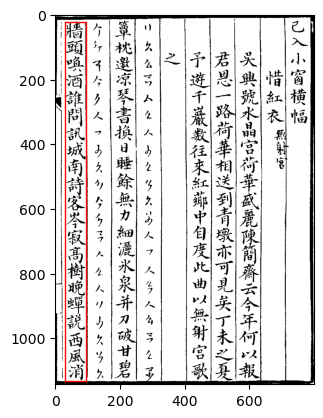

In [699]:
suzipu_songs = [
    book[5][0][4], book[5][0][22], book[5][0][23], book[5][0][24],
    book[7][0][0],
]
suzipu_songs += book[8][0][:]
suzipu_songs += book[9][0][:3]

for song in suzipu_songs:
    print(song)
    
song_idx = 11
line_idx = 8
    
plt.figure()
line = suzipu_songs[song_idx].physical_lines[line_idx]
print(line.page())
plt.imshow(Image.open(os.path.join(edition_directory, "images", line.page())), cmap="gray")
(x, y), (x2, y2) = line.coordinates()

rect = patches.Rectangle((x, y), x2-x, y2-y, linewidth=1, edgecolor='r', facecolor='none')
plt.gca().add_patch(rect)

In [572]:
print(BeautifulSoup(book.to_tei(), features="xml"))

<?xml version="1.0" encoding="utf-8"?>
<?xml-model href="http://www.tei-c.org/release/xml/tei/custom/schema/relaxng/tei_all.rng" type="application/xml" schematypens="http://relaxng.org/ns/structure/1.0"?><?xml-model href="http://www.tei-c.org/release/xml/tei/custom/schema/relaxng/tei_all.rng" type="application/xml" schematypens="http://purl.oclc.org/dsdl/schematron"?><TEI xmlns="http://www.tei-c.org/ns/1.0"><teiHeader> <fileDesc> <titleStmt> <title xml:lang="zh">白石道人歌曲</title> <title type="pinyin" xml:lang="zh">Baishidaoren Gequ</title> <title xml:lang="en">Songs of the Whitestone Daoist</title> <author><persName ref="#person_jiang_kui">Jiang Kui</persName></author> <respStmt> <resp>XML encoding</resp> <persName><forename>Tristan</forename><surname>Repolusk</surname></persName> </respStmt> </titleStmt> <publicationStmt> <publisher><orgName corresp="https://informationsmodellierung.uni-graz.at" ref="http://d-nb.info/gnd/1137284463">Department of Digital Humanities, University of Graz</o

41
[TextLine(琵琶仙玲瓏四犯此曲雙調世別有大石調一曲), LyricsLine(助我肆伐蜀人號呼乞生于師蜀囚素衣天子憐之), TextLine(望鍾山下江南也李煜乍臣乍叛勢窮乃降而我師), LyricsLine(一姓吁不仁瞻彼日月爝火敢出震震皇皇帝命是式), LyricsLine(為日月出照玉墀吁嗟仁𠔃帝乗輅六龍儛神示下繹), TextLine(琴七絃散聲具宫商角徵羽者為正弄慢角清商), TextLine(此調甚流美也蓋慢角乃黄鍾之正側商乃黄鍾), TextLine(慢角調慢四一暉取二𢎺十一暉應慢六一暉取四𢎺十暉應), LyricsLine(合下四四下一一上勾尺下工工下凡凡六下五五一五), LyricsLine(才因老𥁞秀句君休覔萬緑正迷人更愁入山陽夜笛), LyricsLine(又妬腰肢近平聲前舞絲絲), TextLine(丙辰冬自無錫𨺔作此寓意仙吕調), LyricsLine(香亭北又青苔唯有當時蝴蝶自飛來), LyricsLine(桃葉渡江時 扁舟載了匆匆𨺔去今夜泊前溪楊桺), TextLine(擷以藤糺纏著楓上少焉月出大於黄金盆逸興), TextLine(一曰濩𢎺梁州轉闗緑綠腰醉吟商湖渭州歴𢎺薄媚也), TextLine(遇琵琶工解作醉吟商湖渭州因求得品𢎺法譯), TextLine(玉梅令高平調), TextLine(齊天樂黄鍾宫), LyricsLine(相和碪杵候館迎秋離宫吊月別有傷心無數豳詩謾), LyricsLine(與笑籬落呼燈世間兒女寫入琴絲一聲聲更苦宣政間有士大), LyricsLine(夫製蟋蟀吟), LyricsLine(山命駕羣龍金作軛相從諸娣玉為冠廟中列坐如夫人者十三人向夜), TextLine(眉嫵一名百宜嬌戲仲逺), TextLine(法曲獻仙音俗名大石 黄鍾商), TextLine(琵琶仙黄鍾商), LyricsLine(玉珂朱組又占了道人林下真趣窗戶新成青紅猶潤), TextLine(楊州慢中呂宫), TextLine(予懷愴然感慨今昔因自度此曲千巖老人以為), TextLine(長亭怨慢中呂宫), TextLine(淡黄桺正平調近), TextLine(石湖仙越調夀石湖居士), TextLine(暗香仙呂宫), LyricsLine(西湖寒碧又片片吹盡也幾時見得), TextLine(惜紅衣無射宮), TextLi

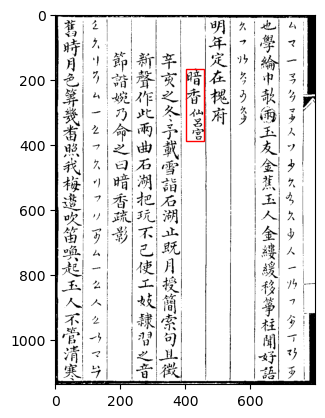

In [573]:
line_idx = 5
line_idx = 10
line_idx = 15
line_idx = 18
line_idx = 19
line_idx = 26
line_idx = 32

print(len(book.suspicious_lines))
print(book.suspicious_lines)
plt.figure()
line = book.suspicious_lines[line_idx]
print(line.page())
plt.imshow(Image.open(os.path.join(edition_directory, "images", line.page())), cmap="gray")
(x, y), (x2, y2) = line.coordinates()

rect = patches.Rectangle((x, y), x2-x, y2-y, linewidth=1, edgecolor='r', facecolor='none')
plt.gca().add_patch(rect)

In [561]:
def transform_juan_to_tei(juan_path: str):
    tei_string = ""
    all_jsons = sorted(os.listdir(juan_path))
    
    pieces = [json for json in all_jsons if json[0].isnumeric()]
    others = [json for json in all_jsons if not json[0].isnumeric()]
    
    for other in others:
        tei_string += transform_juan_description_to_tei(os.path.join(juan, other))
            
    for piece in pieces:
        tei_string += transform_piece_to_tei(os.path.join(juan, piece))
            
    return f'<div type="juan">{tei_string}</div>'

In [562]:
def transform_book_to_tei(juan_division: list[str], other: str):
    tei_string = ""
    
    # Table of Contents
    # Juan 1: 01_shengsongnaogeguchuiqushisishou, 02_qinquyishou
    tei_string 
    # Juan 2: 03_yuejiuge
    # Juan 3: 04_ling
    # Juan 4: 05_man
    # Juan 5: 06_ziduqu
    # Juan 6: 07_zizhiqu
    # Appendix: 08_bieji
        
    return f'<div type="book">{tei_string}</div>'
    #return f'<div type="book" style="writing-mode: vertical-rl">{tei_string}</div>'

In [563]:


book = Book(
    body=[
        Juan(
            information_file=edition_directory + "./json/06_ziduqu/ziduqu.json",
            children=[
                Section(
                    information_file=edition_directory + "./json/06_ziduqu/ziduqu.json",
                    children=[
                        Song(edition_directory + "./json/06_ziduqu/085_xihongyi.json"),
                        Song(edition_directory + "./json/06_ziduqu/086_jueshao.json"),
                    ]),
            ]),
    ])

MEAN WIDTH: 49.5668358714044


In [565]:
print(book.to_tei())

<?xml version="1.0" encoding="UTF-8"?><?xml-model href="http://www.tei-c.org/release/xml/tei/custom/schema/relaxng/tei_all.rng" type="application/xml" schematypens="http://relaxng.org/ns/structure/1.0"?><?xml-model href="http://www.tei-c.org/release/xml/tei/custom/schema/relaxng/tei_all.rng" type="application/xml" schematypens="http://purl.oclc.org/dsdl/schematron"?><TEI xmlns="http://www.tei-c.org/ns/1.0"><teiHeader> <fileDesc> <titleStmt> <title xml:lang="zh">白石道人歌曲</title> <title xml:lang="zh" type="pinyin">Baishidaoren Gequ</title> <title xml:lang="en">Songs of the Whitestone Daoist</title> <author><persName ref="#person_jiang_kui">Jiang Kui</persName></author> <respStmt> <resp>XML encoding</resp> <persName><forename>Tristan</forename><surname>Repolusk</surname></persName> </respStmt> </titleStmt> <publicationStmt> <publisher><orgName corresp="https://informationsmodellierung.uni-graz.at" ref="http://d-nb.info/gnd/1137284463">Department of Digital Humanities, University of Graz</or

In [567]:

for idx, line in enumerate(book[0][0][0].physical_lines):
    print(f"{idx:02d}", line[0]["tei_lb"], line)


00 line_0003 TextLine(惜紅衣無射宮)
01 line_0004 TextLine(吳興號水晶宫荷華盛麗陳簡齋云今年何以報)
02 line_0005 TextLine(君恩一路荷華相送到青墩亦可見矣丁未之夏)
03 line_0006 TextLine(予遊千巖数往來紅薌中自度此曲以無射宫歌)
04 line_0007 TextLine(之)
05 line_0008 MusicLine(*********************)
06 line_0009 LyricsLine(簟枕邀凉琴書換日睡餘無力細灑氷泉并刀破甘碧)
07 line_0010 MusicLine(*********************)
08 line_0011 LyricsLine(牆頭喚酒誰問訊城南詩客岑寂髙樹晚蟬說西風消)
09 line_0012 MusicLine(**)
10 line_0013 LyricsLine(息 )
11 line_0014 MusicLine(*******************)
12 line_0015 LyricsLine(虹梁水陌魚浪吹香紅衣半狼籍維舟試望故國)
13 line_0016 MusicLine(*********************)
14 line_0017 LyricsLine(眇天北可惜栁邉沙外不共羙人遊歷問甚時同賦三)
15 line_0018 MusicLine(******)
16 line_0019 LyricsLine(十六陂秋色 )


In [568]:
print(book[0][0][0].logical_lines[1][0].notation_boxes[0])

{'box_type': 'Music', 'is_excluded_from_dataset': False, 'is_line_break': False, 'text_coordinates': ((634, 133), (682, 169)), 'text_content': '虹', 'notation_coordinates': ((721, 137), (740, 171)), 'notation_content': {'pitch': 'GONG', 'secondary': 'DING_ZHU'}, 'notation_page': 'shanghai_manuscript_082.png', 'text_page': 'shanghai_manuscript_082.png', 'tei_lb': 'line_0014'}


In [569]:
print(book[0][0][0].to_tei())

<div type="song" xml:id="song_085_xihongyi"><head><title>惜紅衣</title><seg rend="small" type="mode">無射宮</seg></head><p ana="description"><lb facs="#line_0004"/>吳興號水晶宫荷華盛麗陳簡齋云今年何以報<lb facs="#line_0005"/>君恩一路荷華相送到青墩亦可見矣丁未之夏<lb facs="#line_0006"/>予遊千巖数往來紅薌中自度此曲以無射宫歌<lb facs="#line_0007"/>之</p><lg><l><lb facs="#line_0008"/><notatedMusic type="suzipu"><desc>凡, 六, 上, 四丁, 尺, 上, 尺, 五, 上, 凡丁, 六, 凡頓, 尺, 工, 尺, 上丁, 尺, 上拽, 四丁, 上, 四頓</desc></notatedMusic><lb facs="#line_0009"/>簟枕邀凉琴書換日睡餘無力細灑氷泉并刀破甘碧<lb facs="#line_0010"/><notatedMusic type="suzipu"><desc>尺拽, 凡丁, 工丁, 尺丁, 凡, 尺, 工, 高, 六, 凡拽, 尺丁, 上拽, 四丁, 尺, 上, 尺, 凡, 五, 六, 凡丁, 六</desc></notatedMusic><lb facs="#line_0011"/>牆頭喚酒誰問訊城南詩客岑寂髙樹晚蟬說西風消<pb n="2r" facs="#shanghai_manuscript_082"/><lb facs="#line_0012"/><notatedMusic type="suzipu"><desc>凡頓</desc></notatedMusic><lb facs="#line_0013"/>息</l><space quantity="1" unit="chars"/><l><lb facs="#line_0014"/><notatedMusic type="suzipu"><desc>工丁, 尺拽, 上丁, 五丁, 凡, 四, 尺, 上, 五, 六, 凡, 六, 凡頓, 工, 尺, 一, 上丁, 工, 凡</desc></not